In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn

## Load Data

Loading the `solar_data.csv` into a pandas DataFrame and displaying the first few rows to verify the data structure.

In [ ]:
import pandas as pd
import os
from google.colab import files

file_path = "/content/Plant_1_Generation_Data.csv"

# Check if file exists, if not, prompt for upload
if not os.path.exists(file_path):
    print(f"File '{file_path}' not found. Please upload it now.")
    uploaded = files.upload()
    if file_path not in uploaded:
        print(f"Error: '{file_path}' was not uploaded. Please ensure you upload the correct file.")
        # Optionally, re-raise the error or handle it differently if the file is still not there
        raise FileNotFoundError(f"'{file_path}' still not found after upload attempt.")
    print(f"File '{file_path}' uploaded successfully.")

df = pd.read_csv(file_path)

print(df.head())

          DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2  15-05-2020 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   
3  15-05-2020 00:00   4135001  7JYdWkrLSPkdwr4       0.0       0.0   
4  15-05-2020 00:00   4135001  McdE0feGgRqW7Ca       0.0       0.0   

   DAILY_YIELD  TOTAL_YIELD  
0          0.0    6259559.0  
1          0.0    6183645.0  
2          0.0    6987759.0  
3          0.0    7602960.0  
4          0.0    7158964.0  


## Data Cleaning

Checking for missing values, dropping rows with `NaN` values, and converting the `date_time` column to datetime objects.

In [ ]:
print('Missing values before cleaning:')
print(df.isnull().sum())

df = df.dropna()

# Correcting the column name from 'date_time' to 'DATE_TIME' for conversion
df['date_time'] = pd.to_datetime(df['DATE_TIME'])

print('\nMissing values after cleaning:')
print(df.isnull().sum())
print('\nDate_time column type after conversion:')
print(df['date_time'].dtype)

Missing values before cleaning:
DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
date_time      0
dtype: int64

Missing values after cleaning:
DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
date_time      0
dtype: int64

Date_time column type after conversion:
datetime64[ns]


/tmp/ipykernel_4889/790778292.py:7: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date_time'] = pd.to_datetime(df['DATE_TIME'])


## Feature Engineering
Extracting `hour`, `day`, and `month` from the `date_time` column to create new features.

In [ ]:
df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.day
df['month'] = df['date_time'].dt.month

print(df.head())

          DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2  15-05-2020 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   
3  15-05-2020 00:00   4135001  7JYdWkrLSPkdwr4       0.0       0.0   
4  15-05-2020 00:00   4135001  McdE0feGgRqW7Ca       0.0       0.0   

   DAILY_YIELD  TOTAL_YIELD  date_time  hour  day  month  
0          0.0    6259559.0 2020-05-15     0   15      5  
1          0.0    6183645.0 2020-05-15     0   15      5  
2          0.0    6987759.0 2020-05-15     0   15      5  
3          0.0    7602960.0 2020-05-15     0   15      5  
4          0.0    7158964.0 2020-05-15     0   15      5  


## 📊 STEP 6 — Statistical Analysis (REPORT CONTENT)

Generating descriptive statistics for the DataFrame. This will help us understand the distribution of the data, including mean and maximum power.

In [ ]:
print(df.describe())

        PLANT_ID      DC_POWER      AC_POWER   DAILY_YIELD   TOTAL_YIELD  \
count    68778.0  68778.000000  68778.000000  68778.000000  6.877800e+04   
mean   4135001.0   3147.426211    307.802752   3295.968737  6.978712e+06   
min    4135001.0      0.000000      0.000000      0.000000  6.183645e+06   
25%    4135001.0      0.000000      0.000000      0.000000  6.512003e+06   
50%    4135001.0    429.000000     41.493750   2658.714286  7.146685e+06   
75%    4135001.0   6366.964286    623.618750   6274.000000  7.268706e+06   
max    4135001.0  14471.125000   1410.950000   9163.000000  7.846821e+06   
std          0.0   4036.457169    394.396439   3145.178309  4.162720e+05   

                           date_time          hour           day         month  
count                          68778  68778.000000  68778.000000  68778.000000  
mean   2020-06-01 08:02:49.458256896     11.567216     15.762133      5.518567  
min              2020-05-15 00:00:00      0.000000      1.000000      5.

## 📈 STEP 7 — MAIN GRAPH (CORE REQUIREMENT)

Generating a line plot of solar power output over time to visualize trends.

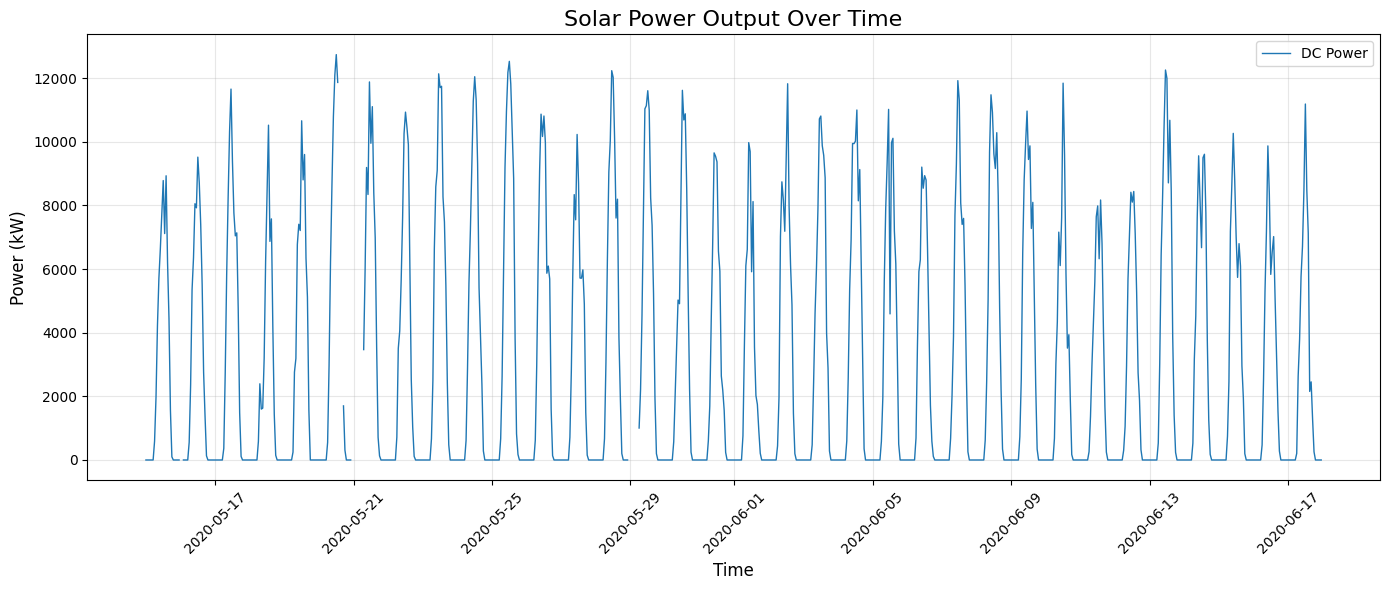

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# Reduce density by resampling to 1-hour intervals (mean)
df_resampled = df.resample('1h', on='date_time').mean(numeric_only=True)

plt.plot(df_resampled.index, df_resampled['DC_POWER'], label='DC Power', linewidth=1)

plt.title("Solar Power Output Over Time", fontsize=16)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Power (kW)", fontsize=12)

plt.legend()
plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
plt.savefig("time_series.png")

## ⏱ STEP 8 — DAILY TREND (VERY IMPORTANT GRAPH)

Plotting the average power output by hour to identify daily generation patterns.

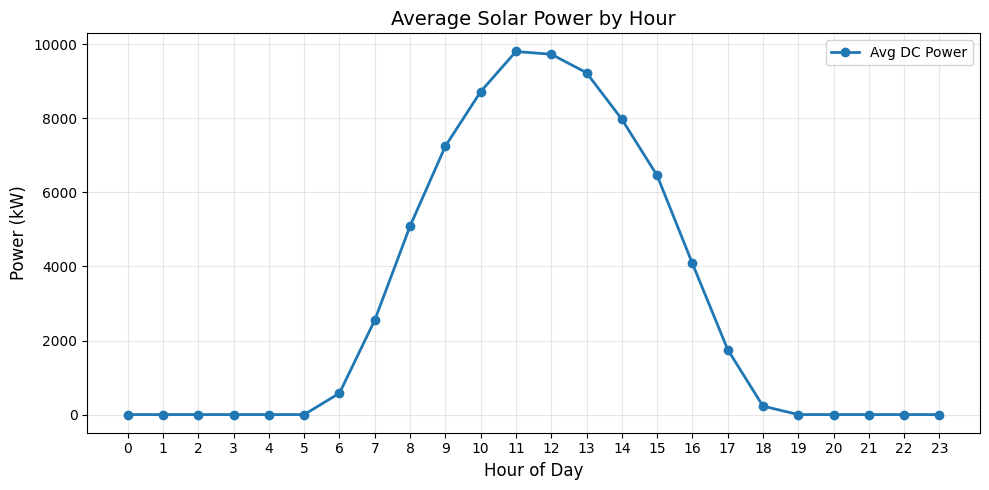

In [ ]:
import matplotlib.pyplot as plt

hourly_avg = df.groupby('hour')['DC_POWER'].mean()

plt.figure(figsize=(10,5))

plt.plot(hourly_avg.index, hourly_avg.values,
         marker='o', linewidth=2, label='Avg DC Power')

plt.title("Average Solar Power by Hour", fontsize=14)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Power (kW)", fontsize=12)

plt.legend()
plt.grid(alpha=0.3)

plt.xticks(range(0,24))

plt.tight_layout()
plt.show()

## 🔗 STEP 9 — CORRELATION ANALYSIS

Calculating and visualizing the correlation matrix to understand relationships between numerical features.

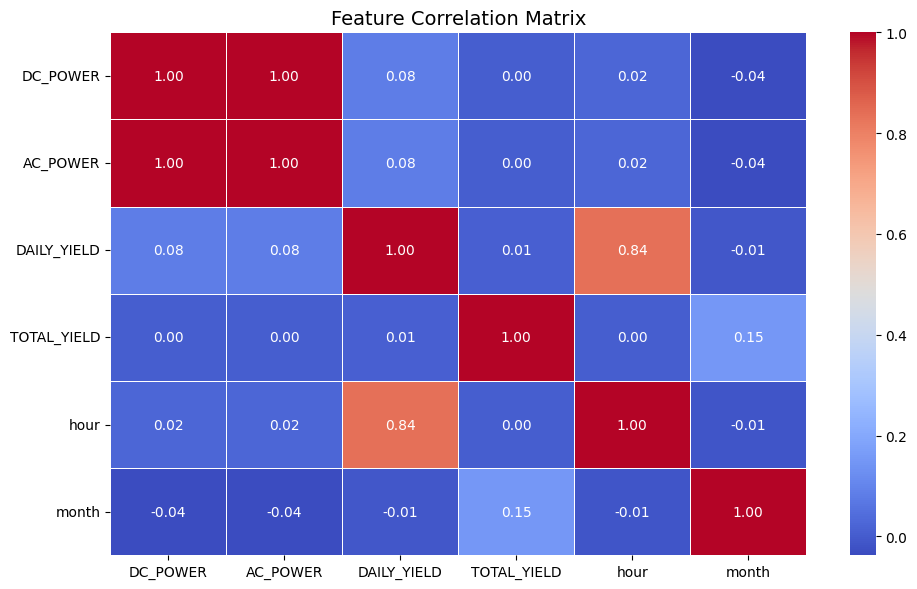

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Selecting relevant numerical columns as per feedback
corr = df[['DC_POWER','AC_POWER','DAILY_YIELD','TOTAL_YIELD','hour','month']].corr()

sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Feature Correlation Matrix", fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# --- FIXING ML LEAKAGE ---
# As per feedback, AC_POWER is removed to avoid data leakage with DC_POWER.
# 'irradiation' and 'temperature' were suggested, but are not present in the current DataFrame.
# Using 'hour' as the primary feature available to predict DC_POWER.

X = df[['hour']]
y = df['DC_POWER']

# Inform the user about missing features
print("Note: 'irradiation' and 'temperature' columns were not found in the dataset.")
print("ML model is trained using 'hour' as the sole feature to avoid data leakage from 'AC_POWER'.")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Note: 'irradiation' and 'temperature' columns were not found in the dataset.
ML model is trained using 'hour' as the sole feature to avoid data leakage from 'AC_POWER'.
Accuracy: 0.00022550938147192223


##
AC Power vs DC Power Scatter Plot

Visualizing the relationship between AC_POWER and DC_POWER, which are expected to be highly correlated.

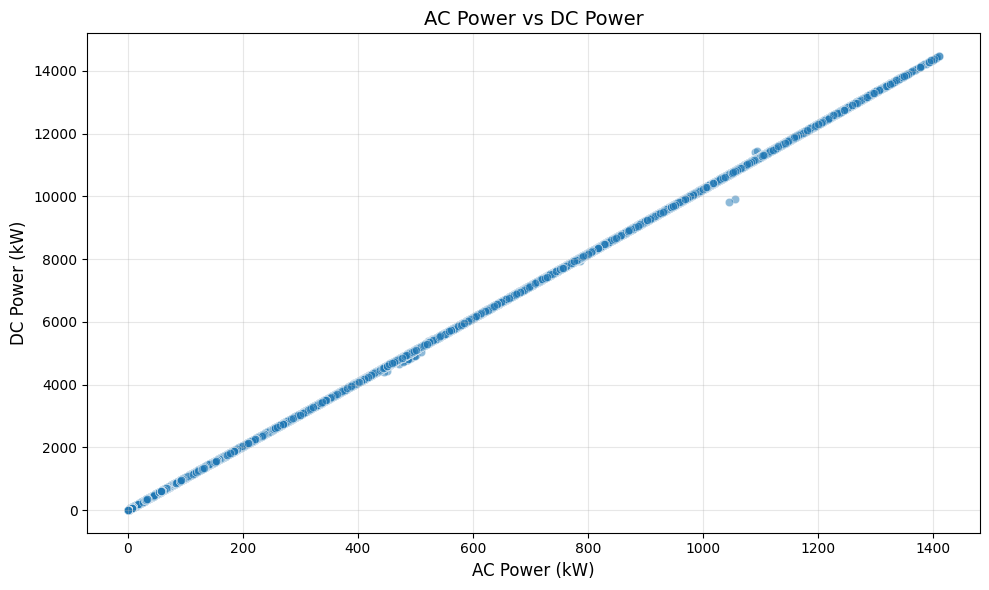

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(x='AC_POWER', y='DC_POWER', data=df, alpha=0.5)
plt.title('AC Power vs DC Power', fontsize=14)
plt.xlabel('AC Power (kW)', fontsize=12)
plt.ylabel('DC Power (kW)', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

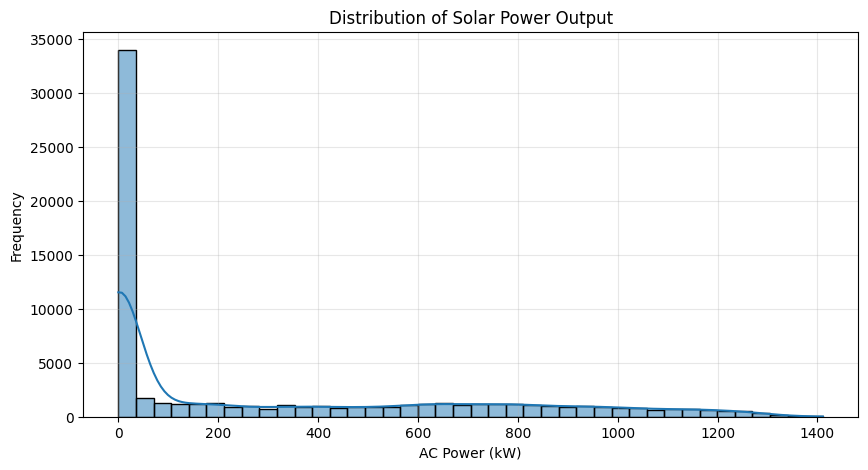

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(df['AC_POWER'], bins=40, kde=True)

plt.title("Distribution of Solar Power Output")
plt.xlabel("AC Power (kW)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()